# Implementing ANNs with TensorFlow - Homework 03 (Group 4)

## Assignment: MNIST classification

###2.1 Loading the Mnist dataset

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

# load the data
(train_ds, test_ds), ds_info = tfds.load ('mnist', split =['train', 'test'], as_supervised = True, with_info = True)

# only use a subset of the data to accelerate the training process
train_ds = train_ds.take(5000)
test_ds = test_ds.take(500)

Dl Completed...:   0%|          | 0/4 [00:00<?, ? file/s]

Dataset mnist downloaded and prepared to ~/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


**How many training/test images are there?**

> There are 10000 images in the 'test' data set, while there are 60000 images in the 'train' data set.

**What's the image shape?**

> The images hold 28x28 pixels, implying greyscale values.

**What range are pixel values in?**

> Pixel values range from 0 (white) to 255 (black). Therefore, lower numbers indicate lightness, and higher numbers indicate darkness.

###2.2 Setting up the data pipeline

In [ ]:
def prepare_data(mnist, batch_size=32):
  """
  This function is used to prepare the raw data for training and testing.

  Arguments:
  mnist -- (a subset of) the MNIST dataset
  batch_size -- denotes the batch size (default is 32)
  """
  # flatten the images into vectors
  mnist = mnist.map(lambda img, target: (tf.reshape(img, (-1,)), target))
  # convert images to float32 data type
  mnist = mnist.map(lambda img, target: (tf.cast(img, tf.float32), target))
  # project the pixel values into range [-1, 1]
  mnist = mnist.map(lambda img, target: ((img/128.)-1., target))
  # represent targets as one-hot vectors
  mnist = mnist.map(lambda img, target: (img, tf.one_hot(target, depth=10)))
  # cache progress into memory
  mnist = mnist.cache()
  # shuffle the data into a random order
  mnist = mnist.shuffle(1000)
  # use batches of a given size
  mnist = mnist.batch(batch_size)
  # prefetch as many data points as we put into a batch
  mnist = mnist.prefetch(batch_size)
  
  return mnist

# prepare training and test data in this manner
train_dataset = train_ds.apply(prepare_data)
test_dataset = test_ds.apply(prepare_data)

###2.3 Building a deep neural network with TensorFlow

In [ ]:
from tensorflow.python.keras.layers import Dense

class MnistModel(tf.keras.Model):
  """
  This subclass of the keras model builds our neural network.
  """

  def __init__ (self, n_hidden_layers=2, hidden_layer_size=256):
    """
    The constructor initiates the layers and their activation functions.

    Arguments:
    n_hidden_layers -- denotes the number of hidden layers (default is 2)
    hidden_layer_size -- denotes the number of neurons in a hidden layer (default is 256)
    """
    super().__init__()
    # instantiate the hidden layers using ReLU as activation function
    self.hidden_layers = []
    for i in range(n_hidden_layers):
      self.hidden_layers.append(tf.keras.layers.Dense(hidden_layer_size, activation=tf.nn.relu))
    # initiate the output layer with softmax as activation function
    self.output_layer = tf.keras.layers.Dense(10, activation=tf.nn.softmax)

  @tf.function
  def call (self, input):
    """
    This function calls the model on new input and returns the output as tensors.

    Arguments:
    input -- denotes the input tensors
    """
    output = input
    # feed the input through the network
    for i, _ in enumerate(self.hidden_layers):
      output = self.hidden_layers[i](output)
    output = self.output_layer(output)

    return output

###2.4.1 Training the network

In [ ]:
def train_step (model, input, target, loss_function, optimizer):
  """
  This function defines a step during the training process.

  Arguments:
  model -- the model object representing our neural network
  input -- the input tensors to the model
  target -- the model targets
  loss_function -- the loss function of the model
  optimizer -- the model optimizer
  """
  with tf.GradientTape() as tape:
    # create the prediction
    prediction = model(input)
    # calculate the loss
    loss = loss_function(target, prediction)
    # check the accuracy
    accuracy = np.argmax(target, axis=1) == np.argmax(prediction, axis=1)
    # calculate the mean accuracy
    accuracy = np.mean(accuracy)
  # calculate the gradients
  gradients = tape.gradient(loss, model.trainable_variables)
  # apply the gradients following the optimizer
  optimizer.apply_gradients(zip(gradients, model.trainable_variables))

  return loss, accuracy


def test(model, test_data, loss_function):
  """
  A function to test how the model performs on the given data.
  Returns the mean loss and accuracy.

  Arguments:
  model -- our neural network
  test_data -- the data used for testing
  loss_function -- the loss function
  """
  # lists to track the accuracies and losses
  test_accuracies = []
  test_losses = []
  # iterate over the test data
  for (input, target) in test_data:
    # create the prediction
    prediction = model(input)
    # calculate the loss
    test_loss = loss_function(target, prediction)
    # check if prediction matches the target
    test_accuracy = np.argmax(target, axis=1) == np.argmax(prediction, axis=1)
    # calculate the mean accuracy
    test_accuracy = np.mean(test_accuracy)
    # store loss and accuracy
    test_losses.append(test_loss.numpy())
    test_accuracies.append(np.mean(test_accuracy))

  # calculate the mean losses and 
  test_loss = tf.reduce_mean(test_losses)
  test_accuracy = tf.reduce_mean(test_accuracies)

  return test_loss, test_accuracy


def training(model, n_epochs, train_data, test_data, loss_function, optimizer):
  """
  Defines the training process of our neural network.
  Returns the training losses and accuracies.

  Arguments:
  model -- the model object representing our neural network
  n_epochs -- the number of training steps
  train_data -- the data set used for training the model
  test_data -- the data set used for testing the model
  loss_function -- the loss function
  optimizer -- the optimizer
  """
  # lists to track training/test losses and accuracies
  train_losses = []
  train_accuracies = []
  test_losses = []
  test_accuracies = []

  # check how our model performs on training data before training
  train_loss, train_accuracy = test(model, train_dataset, loss_function)
  train_losses.append(train_loss)
  train_accuracies.append(train_accuracy)
  # check how our model performs on test data before training
  test_loss, test_accuracy = test(model, test_dataset, loss_function)
  test_losses.append(test_loss)
  test_accuracies.append(test_accuracy)

  # train for given number of epochs
  for epoch in range(n_epochs):
    # print the accuracy before the current epoch
    print(f'Epoch: {str(epoch)} starting with accuracy {test_accuracies[-1]}')
    
    # lists to track losses and accuracies
    epoch_losses = []
    epoch_accuracies = []
    
    # iterate over all images in the data set
    for input, target in train_dataset:
      # update the network and record loss and accuracy
      train_loss, train_accuracy = train_step(model, input, target, loss_function, optimizer)
      epoch_losses.append(train_loss)
      epoch_accuracies.append(train_accuracy)

    # calculate the mean loss and accuracy
    train_losses.append(tf.reduce_mean(epoch_losses))
    train_accuracies.append(tf.reduce_mean(epoch_accuracies))
    
    # track loss and accuracy on the test data
    test_loss, test_accuracy = test(model, test_dataset, loss_function)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

  return train_losses, train_accuracies, test_losses, test_accuracies

###2.4.2 Training the network

In [ ]:
tf.keras.backend.clear_session()

# hyperparameters for the training process
num_epochs = 10
learning_rate = 0.1

# instantiate the model
model = MnistModel()
# our loss function will be categorical cross entropy loss
cross_entropy_loss = tf.keras.losses.CategoricalCrossentropy()
# use stochastic gradient descent as optimizer
sgd_optimizer = tf.keras.optimizers.SGD(learning_rate)

# train the base model
train_losses, train_accuracies, test_losses, test_accuracies = training(model, num_epochs, train_dataset, test_dataset, cross_entropy_loss, sgd_optimizer)

Epoch: 0 starting with accuracy 0.08125
Epoch: 1 starting with accuracy 0.6671875
Epoch: 2 starting with accuracy 0.912109375
Epoch: 3 starting with accuracy 0.539453125
Epoch: 4 starting with accuracy 0.93359375
Epoch: 5 starting with accuracy 0.855859375
Epoch: 6 starting with accuracy 0.933203125
Epoch: 7 starting with accuracy 0.940234375
Epoch: 8 starting with accuracy 0.813671875
Epoch: 9 starting with accuracy 0.75546875


###2.5 Visualization

In [ ]:
def visualization(train_losses, train_accuracies, test_losses, test_accuracies):
  """
  This function visualizes the training progress by showing the mean losses and accuracies after each epoch.

  Arguments:
  train_losses -- denotes the recorded losses during training
  train_accuracies -- accuracies during training
  test_losses -- losses during the test stage
  test_accuracies -- accuracies during testing
  """
  # create the plot grid
  fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(9,6))
  # plot training and test losses and accuracies
  line1, = axes[0].plot(train_losses, color="orange")
  line2, = axes[0].plot(test_losses, color="green")
  line3, = axes[1].plot(train_accuracies, color="orange")
  line4, = axes[1].plot(test_accuracies, color="green")
  # set the axis limits and labels
  axes[0].set(ylim=[0, 3], ylabel="Loss")
  axes[1].set(ylim=[0, 1], xlabel="Training steps", ylabel="Accuracy")
  # create the legend
  axes[0].legend((line1, line2), ("Training","Test"))

  fig.suptitle("Training Progress")

  plt.show()

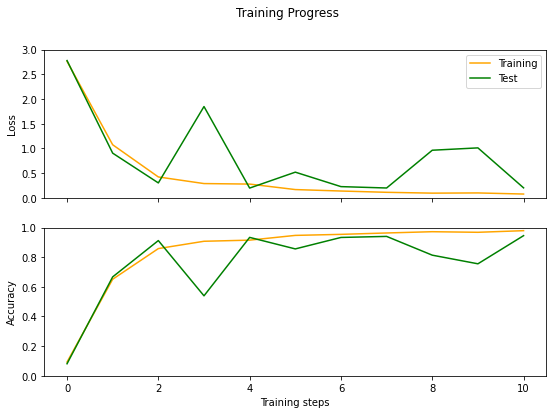

In [ ]:
# show the losses and accuracies of our base model throughout the training process
visualization(train_losses, train_accuracies, test_losses, test_accuracies)

###3 Adjusting the hyperparameters

####Variation 1: One hidden layer with 256 units

Epoch: 0 starting with accuracy 0.111328125
Epoch: 1 starting with accuracy 0.5625
Epoch: 2 starting with accuracy 0.904296875
Epoch: 3 starting with accuracy 0.844921875
Epoch: 4 starting with accuracy 0.8640625
Epoch: 5 starting with accuracy 0.863671875
Epoch: 6 starting with accuracy 0.94609375
Epoch: 7 starting with accuracy 0.9421875
Epoch: 8 starting with accuracy 0.88984375
Epoch: 9 starting with accuracy 0.89140625


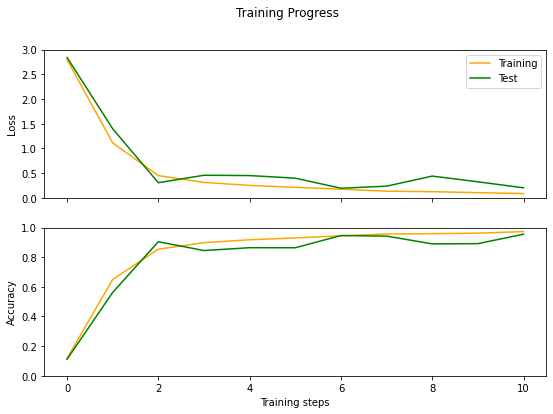

In [ ]:
tf.keras.backend.clear_session()

one_layer_model = MnistModel(n_hidden_layers=1)

train_losses, train_accuracies, test_losses, test_accuracies = training(one_layer_model, num_epochs, train_dataset, test_dataset, cross_entropy_loss, sgd_optimizer)

visualization(train_losses, train_accuracies, test_losses, test_accuracies)

**Remarks:**

Only using one hidden layer with the same number of neurons results in a similar accuracy on training and test data after ten epochs of training.

####Variation 2: One-layer model with 16 neurons

Epoch: 0 starting with accuracy 0.15859375
Epoch: 1 starting with accuracy 0.225
Epoch: 2 starting with accuracy 0.195703125
Epoch: 3 starting with accuracy 0.252734375
Epoch: 4 starting with accuracy 0.237109375
Epoch: 5 starting with accuracy 0.1921875
Epoch: 6 starting with accuracy 0.17265625
Epoch: 7 starting with accuracy 0.270703125
Epoch: 8 starting with accuracy 0.25546875
Epoch: 9 starting with accuracy 0.17265625


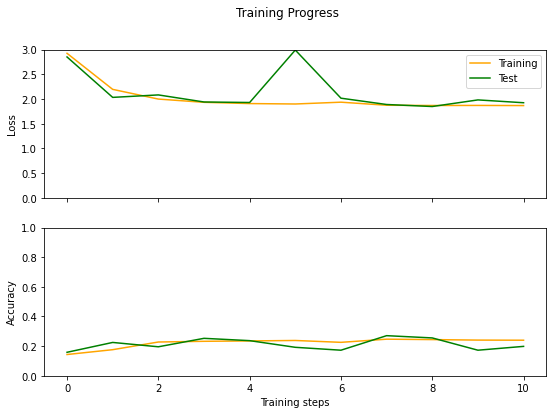

In [ ]:
tf.keras.backend.clear_session()

smaller_model = MnistModel(n_hidden_layers=1, hidden_layer_size=16)

train_losses, train_accuracies, test_losses, test_accuracies = training(smaller_model, num_epochs, train_dataset, test_dataset, cross_entropy_loss, sgd_optimizer)

visualization(train_losses, train_accuracies, test_losses, test_accuracies)

**Remarks:** 

A smaller model with only 16 neurons in one hidden layer performs quite terribly, reaching only about 20% accuracy after training.

####Variation 3: Tweaking the learning rate and momentum of the SGD optimizer



Epoch: 0 starting with accuracy 0.09765625
Epoch: 1 starting with accuracy 0.858203125
Epoch: 2 starting with accuracy 0.898828125
Epoch: 3 starting with accuracy 0.903125
Epoch: 4 starting with accuracy 0.9109375
Epoch: 5 starting with accuracy 0.900390625
Epoch: 6 starting with accuracy 0.92265625
Epoch: 7 starting with accuracy 0.86953125
Epoch: 8 starting with accuracy 0.9140625
Epoch: 9 starting with accuracy 0.91484375


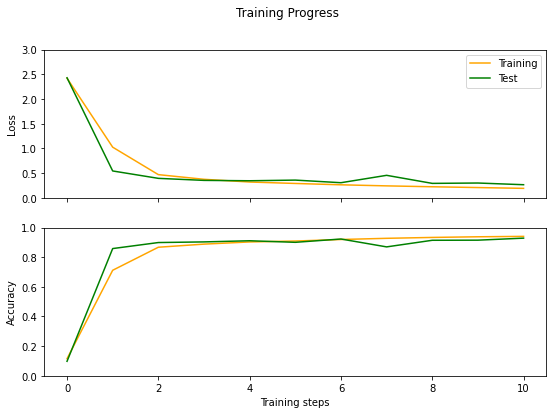

In [ ]:
tf.keras.backend.clear_session()

sgd_optimizer_2 = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.3)

sgd_model = MnistModel()

train_losses, train_accuracies, test_losses, test_accuracies = training(sgd_model, num_epochs, train_dataset, test_dataset, cross_entropy_loss, sgd_optimizer_2)

visualization(train_losses, train_accuracies, test_losses, test_accuracies)

**Remarks:**

Using a smaller learning rate of 0.01 and a momentum of 0.3 on the two-layer model with 256 units per hidden layer, we achieved similar results compared to the base model.

####Variation 4: Smaller network combined with adjustments to SGD optimizer

Epoch: 0 starting with accuracy 0.051171875
Epoch: 1 starting with accuracy 0.774609375
Epoch: 2 starting with accuracy 0.846875
Epoch: 3 starting with accuracy 0.87265625
Epoch: 4 starting with accuracy 0.8953125
Epoch: 5 starting with accuracy 0.867578125
Epoch: 6 starting with accuracy 0.886328125
Epoch: 7 starting with accuracy 0.81796875
Epoch: 8 starting with accuracy 0.8875
Epoch: 9 starting with accuracy 0.903125


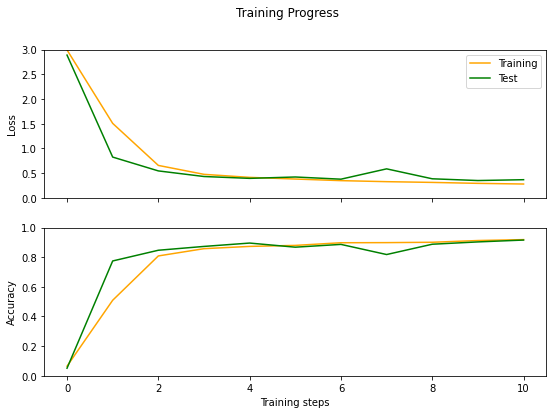

In [ ]:
tf.keras.backend.clear_session()

sgd_optimizer_3 = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.5)

smaller_model = MnistModel(n_hidden_layers=1, hidden_layer_size=16)

train_losses, train_accuracies, test_losses, test_accuracies = training(smaller_model, num_epochs, train_dataset, test_dataset, cross_entropy_loss, sgd_optimizer_3)

visualization(train_losses, train_accuracies, test_losses, test_accuracies)

**Remarks:**

Using a learning rate of 0.01 and an even higher momentum of 0.5, we could achieve more than 90% accuracy on training and test data, while only using one layer with 16 neurons. This is in the realm of the base model, which had far more neurons in its hidden layers.